# Verifying IFS solar forecasts against ERA5 for Madrid

This notebook ([#109](https://github.com/williamhobbs/hefty/issues/109)) verifies hefty's IFS forecasts from [dynamical.org](https://dynamical.org) against ERA5 reanalysis for a hypothetical solar plant near Madrid, Spain. It covers every hourly lead from 1 to 72 hours for each daily 00Z initialization in August 2026.

- **Forecast**: `hefty.solar.get_solar_forecast(model='ifs', priority='dynamical')`, with PV power from `hefty.pv_model.model_pv_power`.
- **Ground truth**: ERA5 from [`pvlib.iotools.get_era5`](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_era5.html), which queries the CDS [ERA5 time-series](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries) API. ERA5 becomes available about 5 days after the fact.
- **Verification**: [xskillscore](https://xskillscore.readthedocs.io) and [climpred](https://climpred.readthedocs.io).

### Credentials
Put your CDS personal access token in a `.env` file at the repository root. `.env` is already listed in `.gitignore`.
```
PRIVATE_CDSAPI_KEY=<your CDS personal access token>
```
You need to accept the ERA5 licence on the CDS website once before the key will work.

### Extra dependencies
hefty does not depend on these packages. Install them, then restart the kernel. pvlib needs nothing extra, because `get_era5` ships with it.

**dynamical.org** (IFS forecast via hefty) and `python-dotenv` (to read `.env`):

In [ ]:
%pip install -q dynamical_catalog cartopy python-dotenv

**Forecast verification**:

In [ ]:
%pip install -q climpred xskillscore

In [3]:
import os
import warnings
from pathlib import Path

import climpred
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import xarray as xr
import xskillscore as xs
from dotenv import find_dotenv, load_dotenv

from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast

warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv(find_dotenv(usecwd=True));

## Site and period
The site is a hypothetical single-axis tracking plant just north of Madrid. The nearest ERA5 grid cell is 40.5°N, 3.75°W.

Each forecast is initialized at 00Z, and every hourly lead from 1 to 72 hours is kept:

- **lead day 0**: leads of 1 to 24 hours, i.e. the day of initialization
- **lead day 1**: leads of 25 to 48 hours, i.e. the next calendar day (day-ahead)
- **lead day 2**: leads of 49 to 72 hours, i.e. the day after that

In [4]:
latitude, longitude = 40.42, -3.70  # Madrid, Spain

plant = dict(
    latitude=latitude,
    longitude=longitude,
    mount_type='single-axis',
    gcr=0.35,
    nameplate_dc=120,  # MW
    nameplate_ac=100,  # MW
    dc_loss_fraction=0.1,
    gamma_pdc=-0.003,
    shade_loss_model='non-linear_simple',
    backtrack=True,
    max_tracker_angle=55,
)

init_dates = pd.date_range('2026-08-01', '2026-08-31', freq='1D')  # 00Z initializations
lead_time_to_start, run_length = 0, 72                             # hours

## ERA5 from pvlib
The CDS time-series API only accepts long variable names. `map_variables=True` renames the output to pvlib's names and units: `ssrd` becomes `ghi` in W/m², and `t2m` becomes `temp_air` in °C. Wind speed is calculated from the 10 m components.

ERA5 radiation is accumulated over the hour **ending** at the timestamp. Shifting the index back 30 minutes puts it at the interval centre, which is the convention hefty uses for forecasts.

In [5]:
era5_start = init_dates[0]
era5_end = init_dates[-1] + pd.Timedelta(hours=lead_time_to_start + run_length)

era5, meta = pvlib.iotools.get_era5(
    latitude, longitude, era5_start, era5_end,
    variables=['surface_solar_radiation_downwards', '2m_temperature',
               '10m_u_component_of_wind', '10m_v_component_of_wind'],
    api_key=os.environ['PRIVATE_CDSAPI_KEY'], timeout=600)
era5['wind_speed'] = np.hypot(era5.pop('u10'), era5.pop('v10'))
era5.index = era5.index - pd.Timedelta('30min')
print(meta['latitude'], meta['longitude'])
era5.head()

40.5 -3.75


,temp_air,ghi,wind_speed
valid_time,,,
2026-07-31 23:30:00+00:00,24.27420,0.0,0.827960
2026-08-01 00:30:00+00:00,23.98818,0.0,0.642175
2026-08-01 01:30:00+00:00,22.79855,0.0,0.729570
2026-08-01 02:30:00+00:00,20.03590,0.0,0.925552
2026-08-01 03:30:00+00:00,19.80330,0.0,1.134786


## IFS forecasts from dynamical.org
See [dynamical_example.ipynb](dynamical_example.ipynb) for more on dynamical. Each call takes about 45 s, so 31 initializations take about 25 minutes the first time. Every forecast is then cached as a CSV under `~/data/hefty_era5_example/`, which makes reruns instant.

In [6]:
cache_dir = Path.home() / 'data' / 'hefty_era5_example'
cache_dir.mkdir(parents=True, exist_ok=True)

def get_ifs_cached(init_date):
    path = cache_dir / (f'ifs_dynamical_{init_date:%Y%m%d%H}_{lead_time_to_start}-{run_length}h'
                        f'_{latitude}_{longitude}.csv')
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True)
    df = get_solar_forecast(
        latitude=latitude, longitude=longitude, init_date=init_date,
        run_length=run_length, lead_time_to_start=lead_time_to_start,
        model='ifs', attempts=3, priority='dynamical')
    df.to_csv(path)
    return df

fcasts = {init: get_ifs_cached(init) for init in init_dates}
fcasts[init_dates[0]].head()

,point,temp_air,wind_speed,wind_direction,lead_time,ghi_csi,ghi,dni,dhi,ghi_clear
valid_time,,,,,,,,,,
2026-08-01 00:30:00+00:00,0,25.062500,1.069794,37.887386,0.5,0.000000,0.0,0.0,0.0,NaN
2026-08-01 01:30:00+00:00,0,24.187500,1.168780,33.601610,1.5,0.000000,0.0,0.0,0.0,NaN
2026-08-01 02:30:00+00:00,0,23.312500,1.267765,29.315832,2.5,0.000000,0.0,0.0,0.0,NaN
2026-08-01 03:30:00+00:00,0,22.666666,1.329840,34.080173,3.5,0.755832,0.0,0.0,0.0,0.0
2026-08-01 04:30:00+00:00,0,22.250000,1.355005,47.894638,4.5,0.755832,0.0,0.0,0.0,0.0


## PV power and xarray datasets
The hourly PV power for each forecast and for ERA5 comes from `model_pv_power`. ERA5 provides only GHI, so DNI and DHI are estimated with the Erbs decomposition, as hefty does for forecasts by default. Albedo is set to 0.2 for both.

For verification, all timestamps are moved to the **end** of each hourly interval, matching ERA5's native convention. Lead `L` of a forecast initialized at `init` is then valid at `init + L` hours. The data is arranged the way climpred expects:

- `fc`: forecasts with `init` and `lead` dimensions
- `obs`: ERA5 with a `time` dimension

In [7]:
def add_decomposition(df):
    df = df.copy()
    sp = pvlib.solarposition.get_solarposition(df.index, latitude, longitude)
    erbs = pvlib.irradiance.erbs(df['ghi'], sp['zenith'], df.index)
    df['dni'], df['dhi'] = erbs['dni'], erbs['dhi']
    return df

def pv_power(resource):
    resource = resource.copy()
    resource['albedo'] = 0.2
    return model_pv_power(resource_data=resource, **plant)[0]

def to_interval_end(df):
    return df.set_axis((df.index + pd.Timedelta('30min')).tz_convert(None))

# ERA5: time
era5_resource = add_decomposition(era5)
obs_df = to_interval_end(pd.DataFrame({'ghi': era5_resource['ghi'], 'power': pv_power(era5_resource)}))
obs = obs_df.rename_axis('time').to_xarray()

# forecasts: init x lead
rows = []
for init, f in fcasts.items():
    f = f.copy()
    f['power'] = pv_power(f)
    f = to_interval_end(f)
    f['init'] = init
    f['lead'] = ((f.index - init) / pd.Timedelta('1h')).astype(int)
    rows.append(f.rename_axis('valid_time').reset_index())
fc_long = pd.concat(rows, ignore_index=True)
fc_long['lead_day'] = (fc_long['lead'] - 1) // 24

fc = fc_long.set_index(['init', 'lead'])[['ghi', 'power']].to_xarray()
fc.lead.attrs['units'] = 'hours'
fc

<xarray.Dataset> Size: 37kB
Dimensions:  (init: 31, lead: 72)
Coordinates:
  * init     (init) datetime64[us] 248B 2026-08-01 2026-08-02 ... 2026-08-31
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (init, lead) float64 18kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    power    (init, lead) float64 18kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Verification dataset: ERA5 on the same `init` × `lead` grid
For each initialization and lead, this cell picks the ERA5 value at the valid time `init + lead`. The result, `verif`, has the same shape as `fc`, so xskillscore can compare the two directly.

In [8]:
valid_time = fc.init + fc.lead * np.timedelta64(1, 'h')
verif = obs.sel(time=valid_time).drop_vars('time')
verif

<xarray.Dataset> Size: 37kB
Dimensions:  (init: 31, lead: 72)
Coordinates:
  * init     (init) datetime64[us] 248B 2026-08-01 2026-08-02 ... 2026-08-31
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (init, lead) float64 18kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    power    (init, lead) float64 18kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Time series: ERA5 vs each lead day
This shows the first 10 days of August, so the individual days are easier to see.

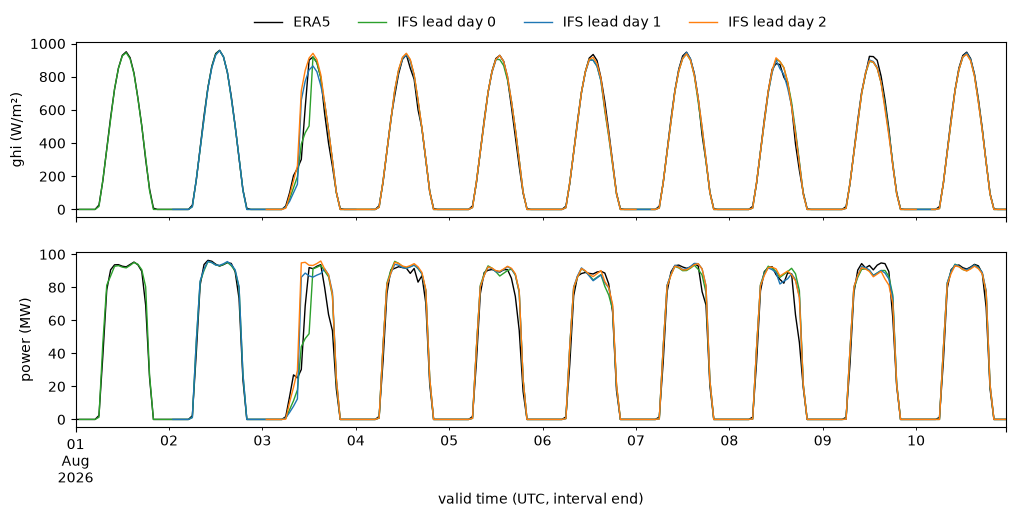

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, var, unit in zip(axes, ['ghi', 'power'], ['W/m²', 'MW']):
    obs_df[var]['2026-08-01':'2026-08-10'].plot(ax=ax, color='black', lw=1, label='ERA5')
    for day, color in [(0, 'tab:green'), (1, 'tab:blue'), (2, 'tab:orange')]:
        s = fc_long[fc_long['lead_day'] == day].set_index('valid_time')[var]['2026-08-01':'2026-08-10']
        s.plot(ax=ax, color=color, lw=1, label=f'IFS lead day {day}')
    ax.set_ylabel(f'{var} ({unit})')
axes[0].legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
axes[1].set_xlabel('valid time (UTC, interval end)')
plt.show()

## Verification
### RMSE by lead with xskillscore
The RMSE is computed over all 31 initializations, giving one value per lead hour.

In [10]:
rmse_xs = xs.rmse(fc, verif, dim='init')
rmse_xs

<xarray.Dataset> Size: 2kB
Dimensions:  (lead: 72)
Coordinates:
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (lead) float64 576B 0.0 0.0 0.0 0.0 0.0 ... 2.22 0.0 0.0 0.0 0.0
    power    (lead) float64 576B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

### RMSE by lead with climpred `verify`
`HindcastEnsemble.verify` lines each forecast up with the observation at its valid time and gives the same result. With `alignment='same_inits'`, every lead hour is scored on the same initializations, just like the xskillscore calculation above.

In [11]:
hindcast = climpred.HindcastEnsemble(fc).add_observations(obs)

def verify(metric):
    return (hindcast.verify(metric=metric, comparison='e2o', dim='init', alignment='same_inits')
            .drop_vars('skill'))

rmse = verify('rmse')
xr.testing.assert_allclose(rmse, rmse_xs)  # identical to xskillscore
rmse

<xarray.Dataset> Size: 2kB
Dimensions:  (lead: 72)
Coordinates:
  * lead     (lead) int64 576B 1 2 3 4 5 6 7 8 9 ... 64 65 66 67 68 69 70 71 72
Data variables:
    ghi      (lead) float64 576B 0.0 0.0 0.0 0.0 0.0 ... 2.22 0.0 0.0 0.0 0.0
    power    (lead) float64 576B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    prediction_skill_software:     climpred https://climpred.readthedocs.io/
    skill_calculated_by_function:  HindcastEnsemble.verify()
    number_of_initializations:     31
    alignment:                     same_inits
    metric:                        rmse
    comparison:                    e2o
    dim:                           init
    reference:                     []

### Plots by lead
For each lead hour, the mean bias (forecast minus ERA5, `metric='me'`) and the RMSE are averaged over all initializations. Night hours, where both forecast and ERA5 are 0, are left blank.

In [12]:
daytime = rmse > 0

def plot_vs_lead(ds, name, ylim_bottom=None):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    for ax, var, unit, color in zip(axes, ['ghi', 'power'], ['W/m²', 'MW'], ['tab:blue', 'tab:green']):
        ds[var].where(daytime[var]).plot(ax=ax, marker='.', color=color)
        for day in (0, 1, 2):
            ax.text(24 * day + 1, 0.88, f'lead day {day}', transform=ax.get_xaxis_transform())
        ax.axvspan(24.5, 48.5, color='grey', alpha=0.1)
        if ylim_bottom is None:
            ax.axhline(0, color='black', lw=0.8)
        else:
            ax.set_ylim(bottom=ylim_bottom)
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel(f'{name} {var} ({unit})')
    axes[1].set_xlim(0.5, 72.5)
    axes[1].set_xlabel('lead (hours, interval end)')
    plt.show()

### Bias vs lead

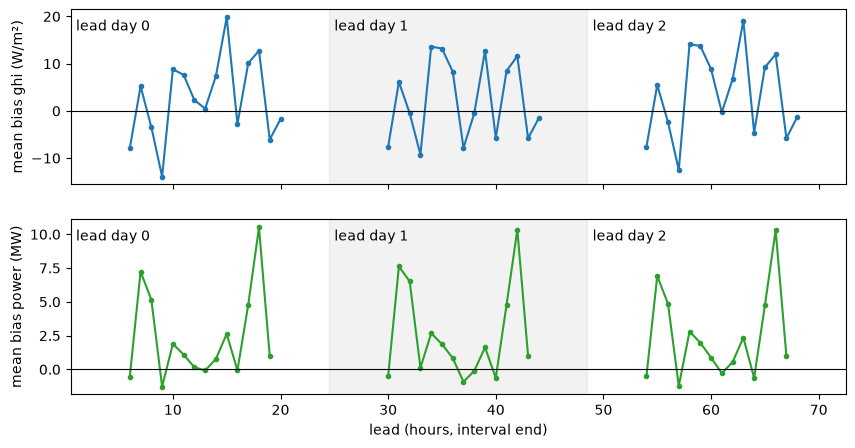

In [13]:
bias = verify('me')
xr.testing.assert_allclose(bias, xs.me(fc, verif, dim='init'))  # identical to xskillscore
plot_vs_lead(bias, 'mean bias')

### Skill vs lead

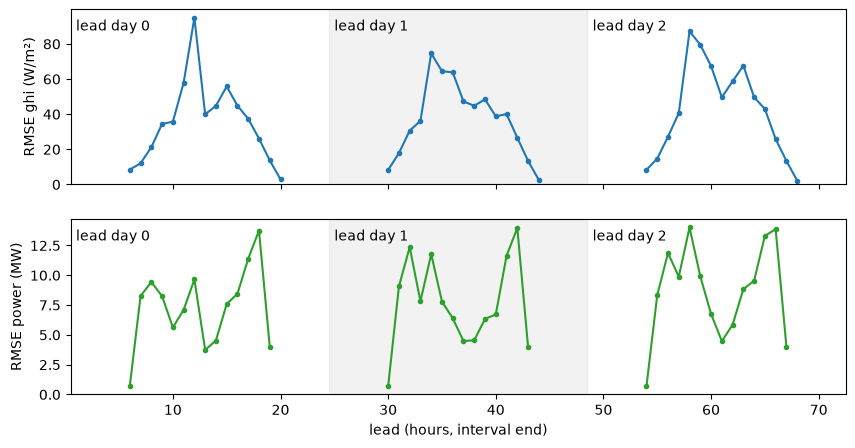

In [14]:
plot_vs_lead(rmse, 'RMSE', ylim_bottom=0)

### Daily energy
Daily energy is what a day-ahead market cares about most. Summing PV power over each lead day gives one value per initialization and lead day:

In [15]:
lead_day = ((fc.lead - 1) // 24).rename('lead_day')
fc_energy = fc['power'].groupby(lead_day).sum()  # MWh per day
obs_energy = verif['power'].groupby(lead_day).sum()

pd.DataFrame({
    'ERA5 mean (MWh/day)': obs_energy.mean('init').to_series(),
    'IFS mean bias (MWh/day)': xs.me(fc_energy, obs_energy, dim='init').to_series(),
    'IFS MAE (MWh/day)': xs.mae(fc_energy, obs_energy, dim='init').to_series(),
    'IFS MAPE (%)': 100 * xs.mape(fc_energy, obs_energy, dim='init').to_series(),
}).round(1)

,ERA5 mean (MWh/day),IFS mean bias (MWh/day),IFS MAE (MWh/day),IFS MAPE (%)
lead_day,,,,
0,907.1,33.2,37.7,4.2
1,903.1,35.2,37.9,4.3
2,898.2,33.7,51.4,6.1


-----
_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/_

_ECMWF Data have been modified using the functions included in the hefty Python package (e.g., interpolation to hourly values)._

_Contains modified Copernicus Climate Change Service information 2026 (ERA5, Hersbach et al., 2023, doi:10.24381/cds.adbb2d47). Neither the European Commission nor ECMWF is responsible for any use that may be made of the Copernicus information or data it contains._